In [16]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()


  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [17]:
using Revise
using CairoMakie
using Statistics
using Random
includet("analysis.jl")


In [85]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

fig_path (generic function with 1 method)

In [109]:
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

# Link-Degree Moments and Dominance Probabilities at Size 2048

This notebook compares the evolution of link-degree moments with one control scalar for
four dataset families at size 2048. For the simply connected reference, the manifoldlike
simply connected dataset is inserted as the scalar-zero baseline.


In [96]:
simply_connected_path = "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_2048_10000/statistics.jld2"

datasets = [
    (; name = "handles", path = "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_genus_2048_10000/statistics.jld2", scalar = :genus, xlabel = L"g", gtr = true, moment = :mean),
    (; name = "pants", path = "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_pants_2048_10000/statistics.jld2", scalar = :num_boundary_cuts, xlabel = L"n_{\text{pants}}", gtr = true, moment = :mean),
    (; name = "(worm-)holes", path = "/Volumes/Causal Set Silo/causal_sets/analysis/destroyed_2048_30000/statistics.jld2", scalar = :rel_num_flips, xlabel = L"\delta_{\text{flips}}", gtr = true, moment = :mean),
    (; name = "KR insertions", path = "/Volumes/Causal Set Silo/causal_sets/analysis/merged_link_prob_tenth_2048_30000/statistics.jld2", scalar = :rel_size_KR, xlabel = L"\delta_{\text{size}}", gtr = false, moment = :mean),
]


4-element Vector{@NamedTuple{name::String, path::String, scalar::Symbol, xlabel::LaTeXString, gtr::Bool, moment::Symbol}}:
 (name = "handles", path = "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_genus_2048_10000/statistics.jld2", scalar = :genus, xlabel = L"$g$", gtr = 1, moment = :mean)
 (name = "pants", path = "/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_pants_2048_10000/statistics.jld2", scalar = :num_boundary_cuts, xlabel = L"$n_{\text{pants}}$", gtr = 1, moment = :mean)
 (name = "(worm-)holes", path = "/Volumes/Causal Set Silo/causal_sets/analysis/destroyed_2048_30000/statistics.jld2", scalar = :rel_num_flips, xlabel = L"$\delta_{\text{flips}}$", gtr = 1, moment = :mean)
 (name = "KR insertions", path = "/Volumes/Causal Set Silo/causal_sets/analysis/merged_link_prob_tenth_2048_30000/statistics.jld2", scalar = :rel_size_KR, xlabel = L"$\delta_{\text{size}}$", gtr = 0, moment = :mean)

In [67]:
function group_histograms_by_scalar(
    hist_scalar_pairs::AbstractVector{<:Tuple{<:AbstractDict,<:Real}};
    integer_scalar::Bool = false,
)
    grouped = Dict{Float64, Vector{Dict}}()
    for (hist, scalar) in hist_scalar_pairs
        key = integer_scalar ? Float64(round(Int, scalar)) : Float64(scalar)
        push!(get!(grouped, key, Dict[]), hist)
    end
    return grouped
end

function group_histograms_by_scalar(
    hist_scalar_pairs::AbstractVector{<:Tuple{<:AbstractVector,<:Real}};
    integer_scalar::Bool = false,
)
    grouped = Dict{Float64, Vector{Vector{Float64}}}()
    for (hist, scalar) in hist_scalar_pairs
        key = integer_scalar ? Float64(round(Int, scalar)) : Float64(scalar)
        push!(get!(grouped, key, Vector{Float64}[]), Float64.(hist))
    end
    return grouped
end

function summarize_hist_group(hists)
    return (
        mean = CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_mean),
        std = CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_std),
        skew = CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_skew),
        exkurt = CausalSetZoology.aggregate_hist_moment(hists, CausalSetZoology.weighted_hist_exkurt),
    )
end

function central_values_and_errors(summaries, field::Symbol)
    stats = getfield.(summaries, field)
    ys = getfield.(stats, :mean)
    ylow = getfield.(stats, :std_lo)
    yhigh = getfield.(stats, :std_hi)
    return ys, ylow, yhigh
end

function load_scalar_family(spec, simply_connected_hists)

    moment_fn = if spec.moment == :mean
        CausalSetZoology.weighted_hist_mean
    elseif spec.moment == :std
        CausalSetZoology.weighted_hist_std
    elseif spec.moment == :skew
        CausalSetZoology.weighted_hist_skew
    elseif spec.moment == :exkurt
        CausalSetZoology.weighted_hist_exkurt
    else
        error("Unsupported moment: $(spec.moment)")
    end

    hist_scalar_pairs = CausalSetZoology.load_histograms_from_paths([spec.path], :degree_hist_link, spec.scalar)[1]
    grouped = group_histograms_by_scalar(hist_scalar_pairs; integer_scalar = spec.scalar in (:genus, :num_boundary_cuts))
    grouped[0.0] = simply_connected_hists
    xs = sort!(collect(keys(grouped)))
    summaries = [summarize_hist_group(grouped[x]) for x in xs]
    moment_values = Dict(x => [moment_fn(h) for h in grouped[x]] for x in xs)
    cmp = spec.gtr ? (>) : (<)
    probs = [
        x == 0.0 ? 0.5 : mean(cmp(a, b) for a in moment_values[x] for b in moment_values[0.0])
        for x in xs
    ]
    return (; spec, xs, grouped, summaries, moment_values, probs)
end


load_scalar_family (generic function with 1 method)

In [24]:
simply_connected_hists = CausalSetZoology.load_histograms_from_paths([simply_connected_path], :degree_hist_link)[1]

4-element Vector{@NamedTuple{name::String, xs::Vector{Float64}, prob::Vector{Float64}}}:
 (name = "genus", xs = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], prob = [0.5, 0.1121, 0.02746, 0.00704, 0.00126, 0.00052, 0.0001, 4.0e-5, 0.0, 0.0, 0.0])
 (name = "pants", xs = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], prob = [0.5, 0.18338, 0.06846, 0.03422, 0.01374, 0.00616, 0.00352, 0.00236, 0.00058, 0.00046, 0.00056])
 (name = "destroyed", xs = [0.0, 0.005000171745236932, 0.005860806210307767, 0.006869332407181241, 0.008051512121397167, 0.009437400769418661, 0.011061347398632144, 0.012964857107962873, 0.01519611397777235, 0.017811412280166097  …  0.11975175180141671, 0.14036118023326818, 0.16451762487787006, 0.1928312583964338, 0.2260176859428432, 0.2649160738275525, 0.31050870939179287, 0.36394771693331707, 0.42658415898265756, 0.5], prob = [0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
 (name = "merged", 

In [144]:
family_results = [
    let result = load_scalar_family(spec, simply_connected_hists)
        (; result..., probs = [p == 0.0 ? 1e-7 : p for p in result.probs])
    end
    for spec in datasets
]

[(; name = r.spec.name, xs = r.xs, prob = r.probs) for r in family_results]


4-element Vector{@NamedTuple{name::String, xs::Vector{Float64}, prob::Vector{Float64}}}:
 (name = "handles", xs = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], prob = [0.5, 0.11005719960278054, 0.029012983151635283, 0.00608300395256917, 0.0016577844311377245, 0.00041560353287536803, 0.00012030947775628626, 5.021929824561403e-5, 7.739938080495356e-6, 5.084745762711865e-6, 5.808325266214908e-7])
 (name = "pants", xs = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0], prob = [0.5, 0.18732681231380338, 0.06749772051536175, 0.03382865612648221, 0.013233033932135728, 0.00643954857703631, 0.0035817214700193424, 0.002732785087719298, 0.0006695876288659794, 0.0004123629112662014, 0.00039670542635658916])
 (name = "(worm-)holes", xs = [0.0, 0.005000171745236932, 0.005860806210307767, 0.006869332407181241, 0.008051512121397167, 0.009437400769418661, 0.011061347398632144, 0.012964857107962873, 0.01519611397777235, 0.017811412280166097  …  0.11975175180141671, 0.1403611802332681

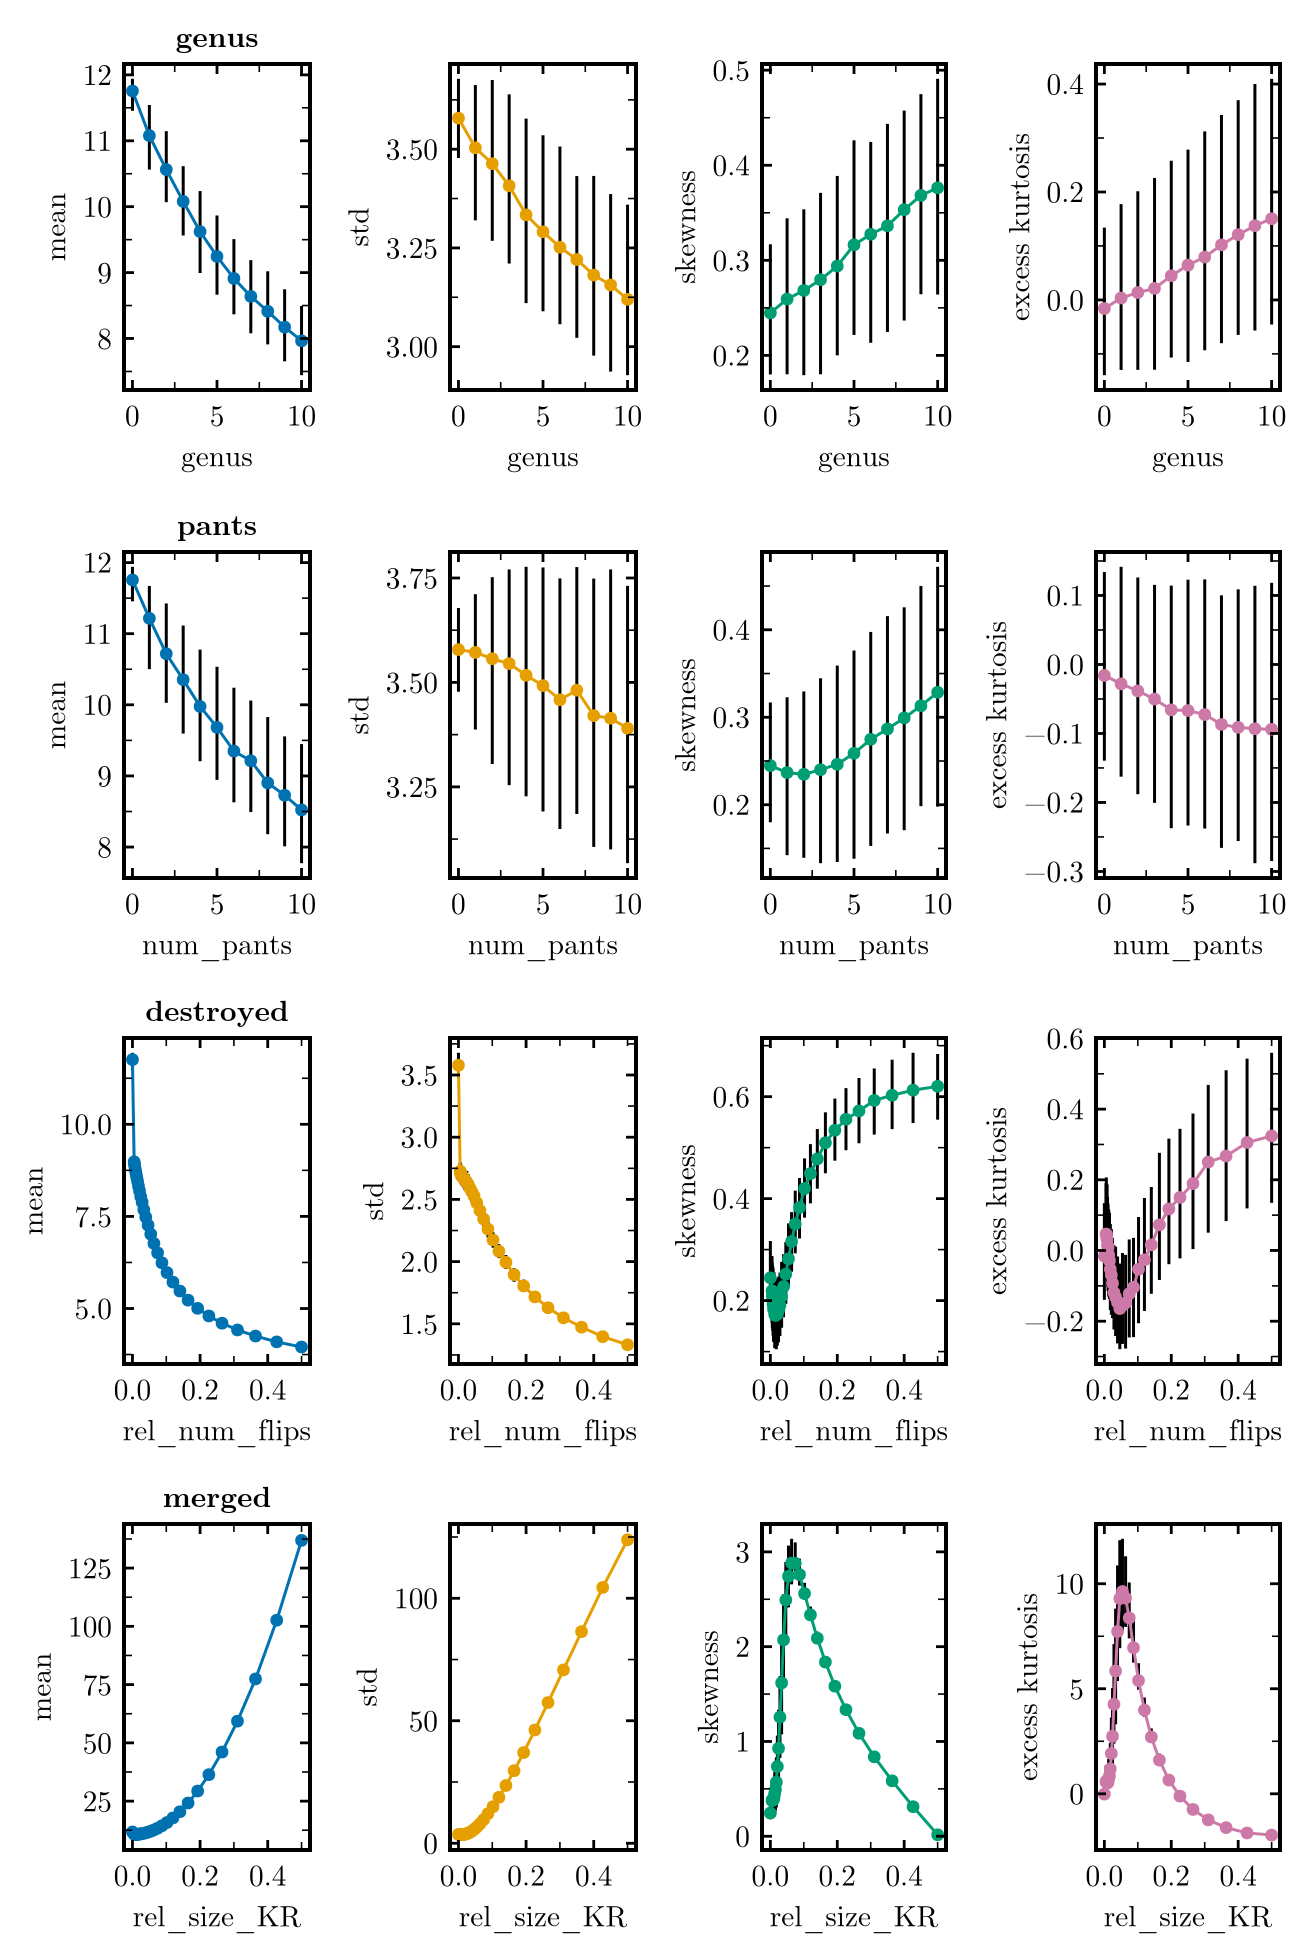

In [45]:
panel_size = apply_paper_theme!(; magnification = 1.0)
fig_mom = Figure(size = (2 * panel_size[1], 4 * panel_size[2]))

moment_specs = [
    (:mean, "mean"),
    (:std, "std"),
    (:skew, "skewness"),
    (:exkurt, "excess kurtosis"),
]

for (row, result) in enumerate(family_results)
    for (col, (field, ylabel)) in enumerate(moment_specs)
        ax = Axis(
            fig_mom[row, col];
            xlabel = result.spec.xlabel,
            ylabel = ylabel,
            title = col == 1 ? result.spec.name : "",
        )
        ys, ylo, yhi = central_values_and_errors(result.summaries, field)
        errorbars!(ax, result.xs, ys, ylo, yhi; color = :black)
        scatterlines!(ax, result.xs, ys; color = Makie.wong_colors()[col], marker = :circle)
    end
end

fig_mom


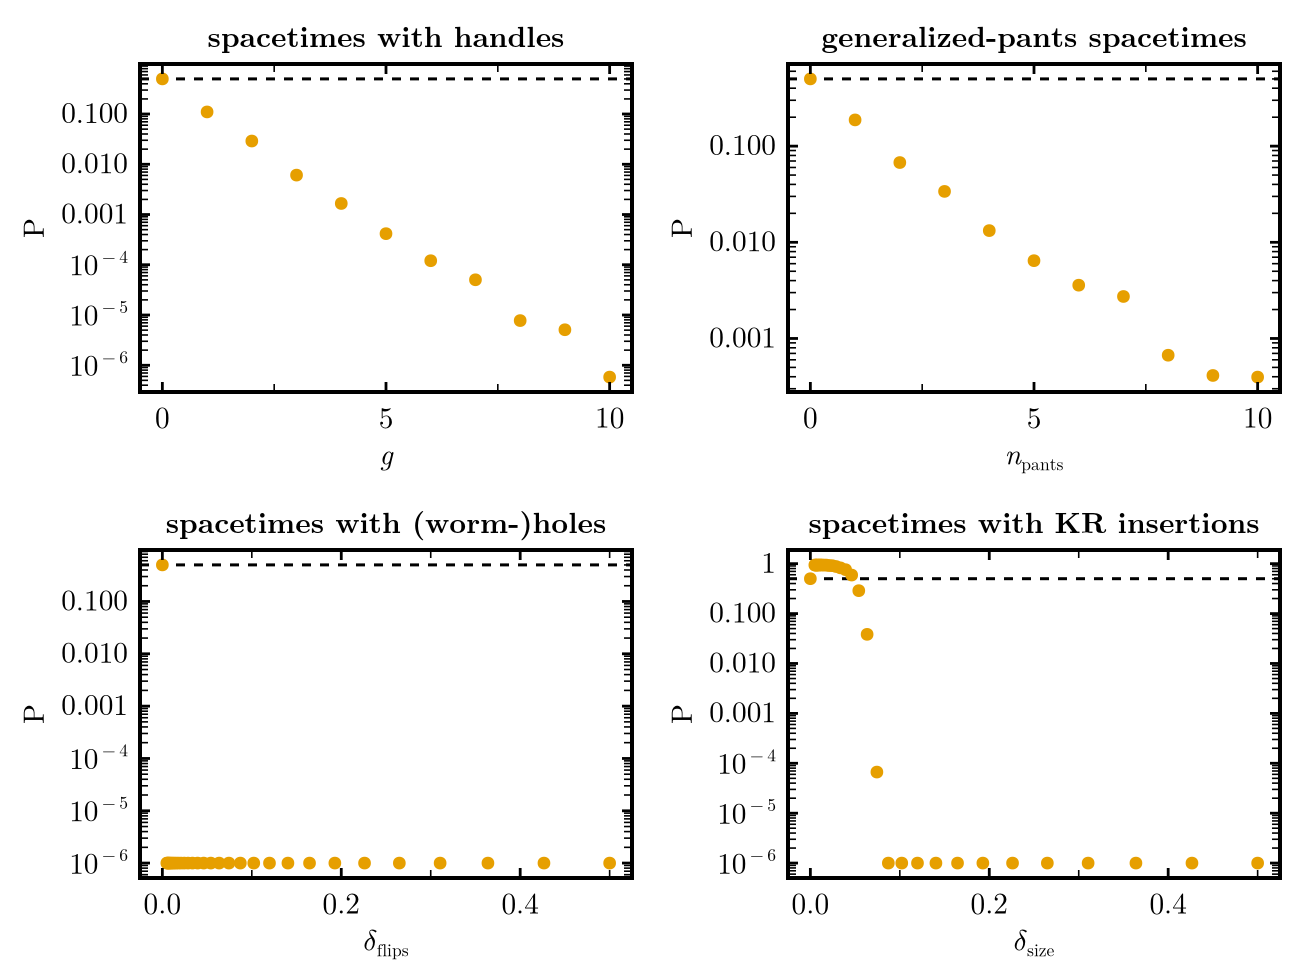

In [84]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y=true,)# logscale_y=true)
fig_prob = Figure(size = (2 * panel_size_prob[1], 2 * panel_size_prob[2]))

for (idx, result) in enumerate(family_results)
    row = fld1(idx, 2)
    col = idx - 2 * (row - 1)
    ax = Axis(
        fig_prob[row, col];
        xlabel = result.spec.xlabel,
        ylabel = "P",
        title = result.spec.name,
        #xscale = log10,
        yscale = log10,

    )
    #xlims!(ax, [1,1,0.001,0.001][idx], 10)
    #ylims!(ax, 1e-8, 1)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash)
    scatter!(ax, result.xs, result.probs; color = Makie.wong_colors()[2], marker = :circle)
end

fig_prob


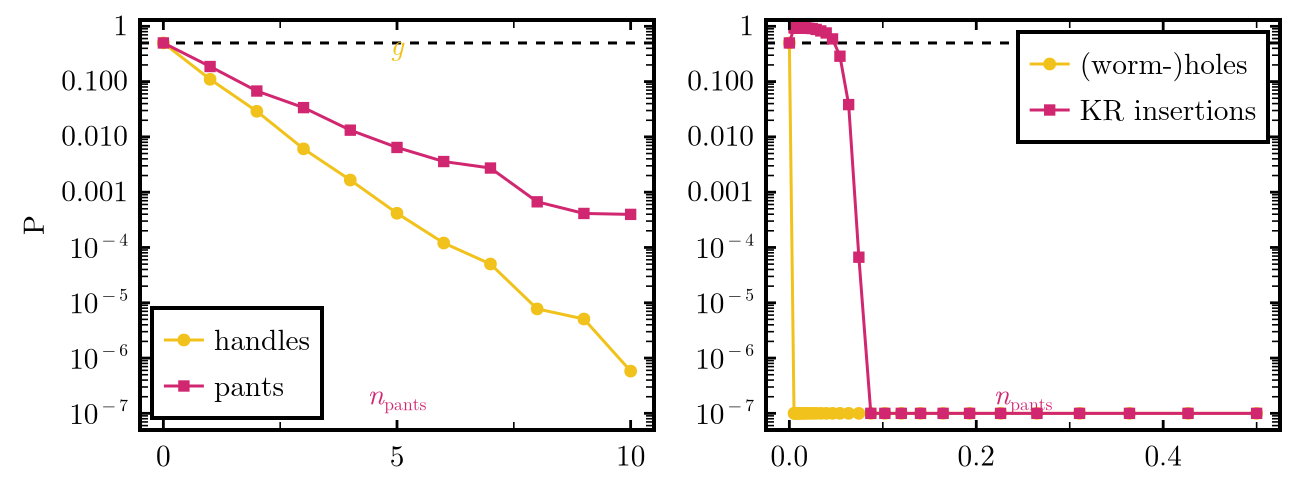

In [172]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y=true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    (["handles", "pants"]),
    (["(worm-)holes", "KR insertions"]),
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

result_by_name = Dict(r.spec.name => r for r in family_results)

for (idx, names) in enumerate(group_specs)
    ax = Axis(
        fig_prob_grouped[1, idx];
        xlabel = "",#[L"g,~n_{\text{pants}}", L"\delta_{\text{flips}},~\delta_{\text{size}}"][idx],
        ylabel = idx == 1 ? "P" : "",
        yscale = log10,
    )
    ylims!(ax, .5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash)
    for name in names
        result = result_by_name[name]
        scatterlines!(
            ax,
            result.xs,
            result.probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end

    text!(ax, 0.5, .9;
        text = L"g",
        color = col["handles"],
        align = (:center, :bottom),
        space = :relative,
    )

    text!(ax, 0.5, 0.12;
        text = L"n_\text{pants}",
        color = col["pants"],
        align = (:center, :top),
        space = :relative,
    )

    axislegend(ax; position = [:lb, :rt][idx])
end

fig_prob_grouped


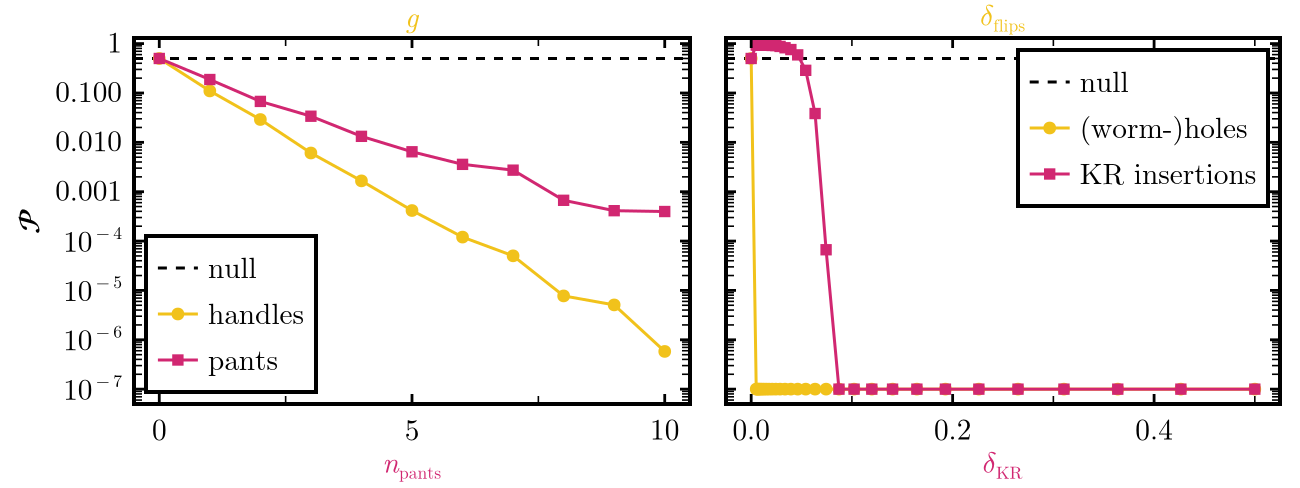

In [ ]:
panel_size_prob = apply_paper_theme!(; magnification = 1.0, logscale_y = true)
fig_prob_grouped = Figure(size = (2 * panel_size_prob[1], panel_size_prob[2]))

group_specs = [
    ["handles", "pants"],
    ["(worm-)holes", "KR insertions"],
]

markers = Dict(
    "handles" => :circle,
    "pants" => :rect,
    "(worm-)holes" => :circle,
    "KR insertions" => :rect,
)

col = Dict(
    "handles" => colors[1],
    "pants" => colors[2],
    "(worm-)holes" => colors[1],
    "KR insertions" => colors[2],
)

top_label = Dict(
    1 => ("g", col["handles"]),
    2 => ("δ_flips", col["(worm-)holes"]),
)

bottom_label = Dict(
    1 => ("n_pants", col["pants"]),
    2 => ("δ_size", col["KR insertions"]),
)

result_by_name = Dict(r.spec.name => r for r in family_results)

for (idx, names) in enumerate(group_specs)
    gl = GridLayout(fig_prob_grouped[1, idx])

    top_text, top_color =
        idx == 1 ? (L"g", col["handles"]) : (L"\delta_{\text{flips}}", col["(worm-)holes"])
    bottom_text, bottom_color =
        idx == 1 ? (L"n_{\text{pants}}", col["pants"]) : (L"\delta_{\text{KR}}", col["KR insertions"])

    Label(gl[1, 1], top_text; color = top_color, tellwidth = false)

    ax = Axis(
        gl[2, 1];
        xlabel = "",
        ylabel = idx == 1 ? L"\mathcal{P}" : "",
        yscale = log10,
        yticklabelsvisible = idx == 1,
    )

    Label(gl[3, 1], bottom_text; color = bottom_color, tellwidth = false)

    rowsize!(gl, 1, Fixed(18))
    rowsize!(gl, 2, Relative(.9))
    rowsize!(gl, 3, Fixed(22))
    rowgap!(gl, 0.5)

    ylims!(ax, .5e-7, 1.3)
    hlines!(ax, [0.5]; color = :black, linestyle = :dash, label = "null")

    for name in names
        result = result_by_name[name]
        scatterlines!(
            ax,
            result.xs,
            result.probs;
            label = name,
            color = col[name],
            marker = markers[name],
        )
    end

    axislegend(ax; position = [:lb, :rt][idx])
end


fig_prob_grouped


In [206]:
save(fig_path("graph_observables/degree_probabilities_panel.pdf"), fig_prob_grouped)

CairoMakie.Screen{PDF}
